#### CSCE 670 :: Information Storage & Retrieval :: Texas A&M University :: Spring 2025


# Homework 2:  Ranking with text and links

### 100 points [4% of your final grade]

### Due: February 24 (Monday) by 11:59pm

*Goals of this homework:* In this homework you will focus on the (i) basics of parsing data and graph building; and (ii) basics of PageRank and HITS.

*Submission instructions (Canvas):* To submit your homework, rename this notebook as `UIN_hw2.ipynb`. For example, my homework submission would be something like `555001234_hw2.ipynb`. Submit this notebook via Canvas (look for the homework 2 assignment there). Your notebook should be completely self-contained, with the results visible in the notebook. We should not have to run any code from the command line, nor should we have to run your code within the notebook (though we reserve the right to do so). So please run all the cells for us, and then submit.

*Late submission policy:* For this homework, you may use as many late days as you like (up to the 5 total allotted to you).

*Collaboration policy:* You are expected to complete each homework independently. Your solution should be written by you without the direct aid or help of anyone else. However, we believe that collaboration and team work are important for facilitating learning, so we encourage you to discuss problems and general problem approaches (but not actual solutions) with your classmates. You may post on Canvas, search StackOverflow, even use ChatGPT. But if you do get help in this way, you must inform us by **filling out the Collaboration Declarations at the bottom of this notebook**. See the course syllabus for details.

*Example: I found helpful code on stackoverflow at https://stackoverflow.com/questions/11764539/writing-fizzbuzz that helped me solve Problem 2.*

The basic rule is that no student should explicitly share a solution with another student (and thereby circumvent the basic learning process), but it is okay to share general approaches, directions, and so on. If you feel like you have an issue that needs clarification, feel free to contact either me or the TA.

# Dataset: Enron Email Dataset

We are providing you with a collection of emails from the Enron Email Dataset. The Enron Email Dataset was collected and prepared by the CALO Project (A Cognitive Assistant that Learns and Organizes). It contains data from about 150 users, mostly senior management of Enron. The full corpus contains a total of about 0.5M messages (https://www.cs.cmu.edu/~enron/).

For this homework, we will use a subset of the dataset. The subset contains the `sent emails` from 78 users in the dataset. We have zipped the dataset and provided it to you on Canvas as `enron_sent_mail.zip`. The zip file is about 45 MB. Each folder contains a subfolder named `_sent_mail` which contains the sent emails of that user. Each email is stored in a separate file, containing the relationship of `who send to whom` as noted by `From:` and `To:` entries. We are going to build a graph using the relationships between the users!


Below is an example of one email.

```text
Message-ID: <33025919.1075857594206.JavaMail.evans@thyme>
Date: Wed, 13 Dec 2000 13:09:00 -0800 (PST)
From: john.arnold@enron.com
To: slafontaine@globalp.com
Subject: re:spreads
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: John Arnold
X-To: slafontaine@globalp.com @ ENRON
X-cc:
X-bcc:
X-Folder: \John_Arnold_Dec2000\Notes Folders\'sent mail
X-Origin: Arnold-J
X-FileName: Jarnold.nsf

saw a lot of the bulls sell summer against length in front to mitigate
margins/absolute position limits/var.  as these guys are taking off the
front, they are also buying back summer.  el paso large buyer of next winter
today taking off spreads.  certainly a reason why the spreads were so strong
on the way up and such a piece now.   really the only one left with any risk
premium built in is h/j now.   it was trading equivalent of 180 on access,
down 40+ from this morning.  certainly if we are entering a period of bearish
to neutral trade, h/j will get whacked.  certainly understand the arguments
for h/j.  if h settles $20, that spread is probably worth $10.  H 20 call was
trading for 55 on monday.  today it was 10/17.  the market's view of
probability of h going crazy has certainly changed in past 48 hours and that
has to be reflected in h/j.




slafontaine@globalp.com on 12/13/2000 04:15:51 PM
To: slafontaine@globalp.com
cc: John.Arnold@enron.com
Subject: re:spreads



mkt getting a little more bearish the back of winter i think-if we get another
cold blast jan/feb mite move out. with oil moving down and march closer flat
px
wide to jan im not so bearish these sprds now-less bullish march april as
well.
```

# Part 1: Parse the Email Data to Build a Graph (50 points)

---

Recall how we parse the email content in HW1. Now, in this part, we're going to parse the dataset to build a graph. So, instead of viewing the world as web pages with hyperlinks (where pages = nodes, hyperlinks = edges), we view it as users in an email network. Over this graph, we can apply classic methods like PageRank and Hubs-and-Authorities to order the users according to some notion of importance.

For the first part, you will complete the following code to construct the graph based on the given data. In this graph, the node is the user and a link between two users is added if user A sent an email to user B. The weight of the link is the number of emails sent between user A and user B.

You will need to write a python code to loop through each email file and extract the sender and receiver of each email.
Specifically, you should extract the sender from the `From: john.arnold@enron.com` and receiver from the `To: slafontaine@globalp.com` fields at the top of each email.

* Use the email address to represent a unique user.
* Remove any space in the email. User lower case for the email address.
* Only extract the email addresses that are in the `From:` and `To:` fields at the top of the email. If the email contains forwarded emails below, you can ignore them.
* Choose a proper data structure to store the unique users and the number of times they appear in the dataset. We will use it to build a graph later.

### Print the number of total emails (5 points)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
# your code here
import os
import re
import pandas as pd

def extract_email_addresses(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        header = {}
        lines = file.readlines()
        collecting_recipients = False
        to_emails = []

        for i, line in enumerate(lines):
            line = line.strip()
            if not line:
                break

            key_value = line.split(':', 1)
            if len(key_value) == 2:
                key, value = key_value
                key = key.lower().strip()
                value = value.strip().lower()
                header[key] = value


                if i == 3 and key == "to":
                    header["to"] = value
                    collecting_recipients = True
                    to_emails.extend(value.split(","))


                    for j in range(i + 1, len(lines)):
                        next_line = lines[j].strip()
                        if not next_line or ":" in next_line:
                            break
                        to_emails.extend(next_line.lower().split(","))

            elif collecting_recipients:
                if line.startswith(" ") or line.startswith("\t"):
                    to_emails.extend(line.lower().split(","))
                else:
                    collecting_recipients = False

    from_email = header.get("from", None)
    to_emails = [email.strip() for email in to_emails if email.strip()]

    return from_email, to_emails



def process_email_dataset(folder_path):
    email_data = []
    total_emails = 0
    unique_emails = set()


    for root, dirs, files in os.walk(folder_path):
        parent_folder = os.path.basename(root)
        if parent_folder == "deleted_items":
            continue

        for file in files:
            if file.startswith("."):
                continue

            file_path = os.path.join(root, file)

            try:
                from_email, to_emails = extract_email_addresses(file_path)


                cleaned_to_emails = {email.strip() for email in to_emails}


                if from_email and from_email not in cleaned_to_emails:

                    total_emails += 1


                    unique_emails.add(from_email)

                unique_emails.update(cleaned_to_emails)


                if from_email:

                    email_data.append({"from": from_email, "to": list(cleaned_to_emails)})



            except Exception as e:
                print(f"Error processing file {file_path}: {e}")


    df = pd.DataFrame(email_data)

    return total_emails, unique_emails, df



folder_path = "/content/drive/My Drive/Masters Spring 2025/Information Storage and Retrieval/enron_sent_mail"
total_count, unique_email_ids, email_df = process_email_dataset(folder_path)

print(f"Total emails: {total_count}")
print(f"Unique email IDs: {len(unique_email_ids)}")
print(email_df.head())

# email_df.to_csv('emails.csv', index=False)
# unique_email_ids.to_csv('unique_emails', index=False)

Total emails: 30057
Unique email IDs: 7012
                       from                               to
0  barry.tycholiz@enron.com         [lsimbalist@yorkton.com]
1  barry.tycholiz@enron.com  [jim_yaremko@keyspancanada.com]
2  barry.tycholiz@enron.com           [paul.lucci@enron.com]
3  barry.tycholiz@enron.com          [dave.fuller@enron.com]
4  barry.tycholiz@enron.com          [david.oxley@enron.com]


### Print the number of unique users (5 points)

In [25]:
# your code here
print(f"Unique email users: {len(unique_email_ids)}")

Unique email users: 7012


### Print the top-5 users ranked by the number of emails they involved in the dataset (5 points)

For example, email 1 we have user A sent to user B, email 2 we have user C sent to user A. Then, user A is involved in 2 emails, user B and C are involved in 1 email. So, the top users are A, B, C.

Your output should look like this:

```text
user emails_involved
john.arnold@enron.com 100
slafontaine@globalp.com 98
......
```

In [26]:
# your code here

from_counts = email_df['from'].value_counts()


to_counts = email_df['to'].explode().value_counts()


combined_counts = from_counts.add(to_counts, fill_value=0)


top5_emails = combined_counts.nlargest(5)

print(top5_emails)

kay.mann@enron.com          4231.0
vince.kaminski@enron.com    3528.0
chris.germany@enron.com     1695.0
eric.bass@enron.com         1453.0
kate.symes@enron.com        1341.0
Name: count, dtype: float64


### Print the top-5 users who sent out the most emails in the dataset (5 points)

Note that here, we only consider the person who sent the email, not the receiver.

Your output should look like this:

```text
user emails_sent
john.arnold@enron.com 100
slafontaine@globalp.com 98
......
```

In [28]:
# Count occurrences in the 'from' column
from_counts = email_df['from'].value_counts()

top5_senders = from_counts.nlargest(5)

print(top5_senders)

from
kay.mann@enron.com          4220
vince.kaminski@enron.com    3464
chris.germany@enron.com     1658
eric.bass@enron.com         1409
kate.symes@enron.com        1323
Name: count, dtype: int64


### Print the top-5 users who received the most emails in the dataset (5 points)

Note that here, we only consider the receiver, not sender.

Your output should look like this:

```text
user emails_received
john.arnold@enron.com 100
slafontaine@globalp.com 98
......
```

In [30]:
# your code here

to_counts = email_df['to'].explode().value_counts()


top5_receivers = to_counts.nlargest(5)

print(top5_receivers)

to
vkaminski@aol.com             1061
suzanne.adams@enron.com        428
shirley.crenshaw@enron.com     304
nmann@erac.com                 285
john.lavorato@enron.com        275
Name: count, dtype: int64


### Let's build the graph! (15 points)

Here we are going to use the `networkx` library to build the graph. You can install the library by running `!pip install networkx`.

We are going to build an `undirected` graph (regardless of who sent to whom). The nodes of the graph are the users (represented by the unique email address) and the edges are the emails sent between the users. The weight of the edge is the number of emails sent between the users.

For example, if user A sent 3 emails to user B, and user B sent 2 emails to user A, then the weight of the edge between A and B is 3+2=5.

In [31]:
import networkx as nx
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

In [52]:
# your code to parse the emails to get the nodes, edges, and weights
# tips: think about what data structure you should use to efficiently collect the information by only looping through the entire dataset once. Consider sets, lists, dictionaries, etc.




edges = {}


for index, row in email_df.iterrows():
    sender = row['from']
    recipients = row['to']

    for recipient in recipients:

        edge = tuple(sorted([sender, recipient]))


        if edge in edges:
            edges[edge] += 1
        else:
            edges[edge] = 1

In [53]:
# your code to create the graph
# note the following is a sample code for illustrating how to build the graph
# feel free the modify the code to suit your needs



G = nx.Graph()


for (user_A, user_B), weight in tqdm(edges.items(), desc="Building graph"):
    G.add_edge(user_A, user_B, weight=weight)

Building graph: 100%|██████████| 11265/11265 [00:00<00:00, 359717.05it/s]


### Visualization of the graph (5 points)

Now you have built the graph. Let's visualize the graph. Use any package you like to visualize the graph.

You can find some examples here: https://networkx.org/documentation/stable/auto_examples/index.html

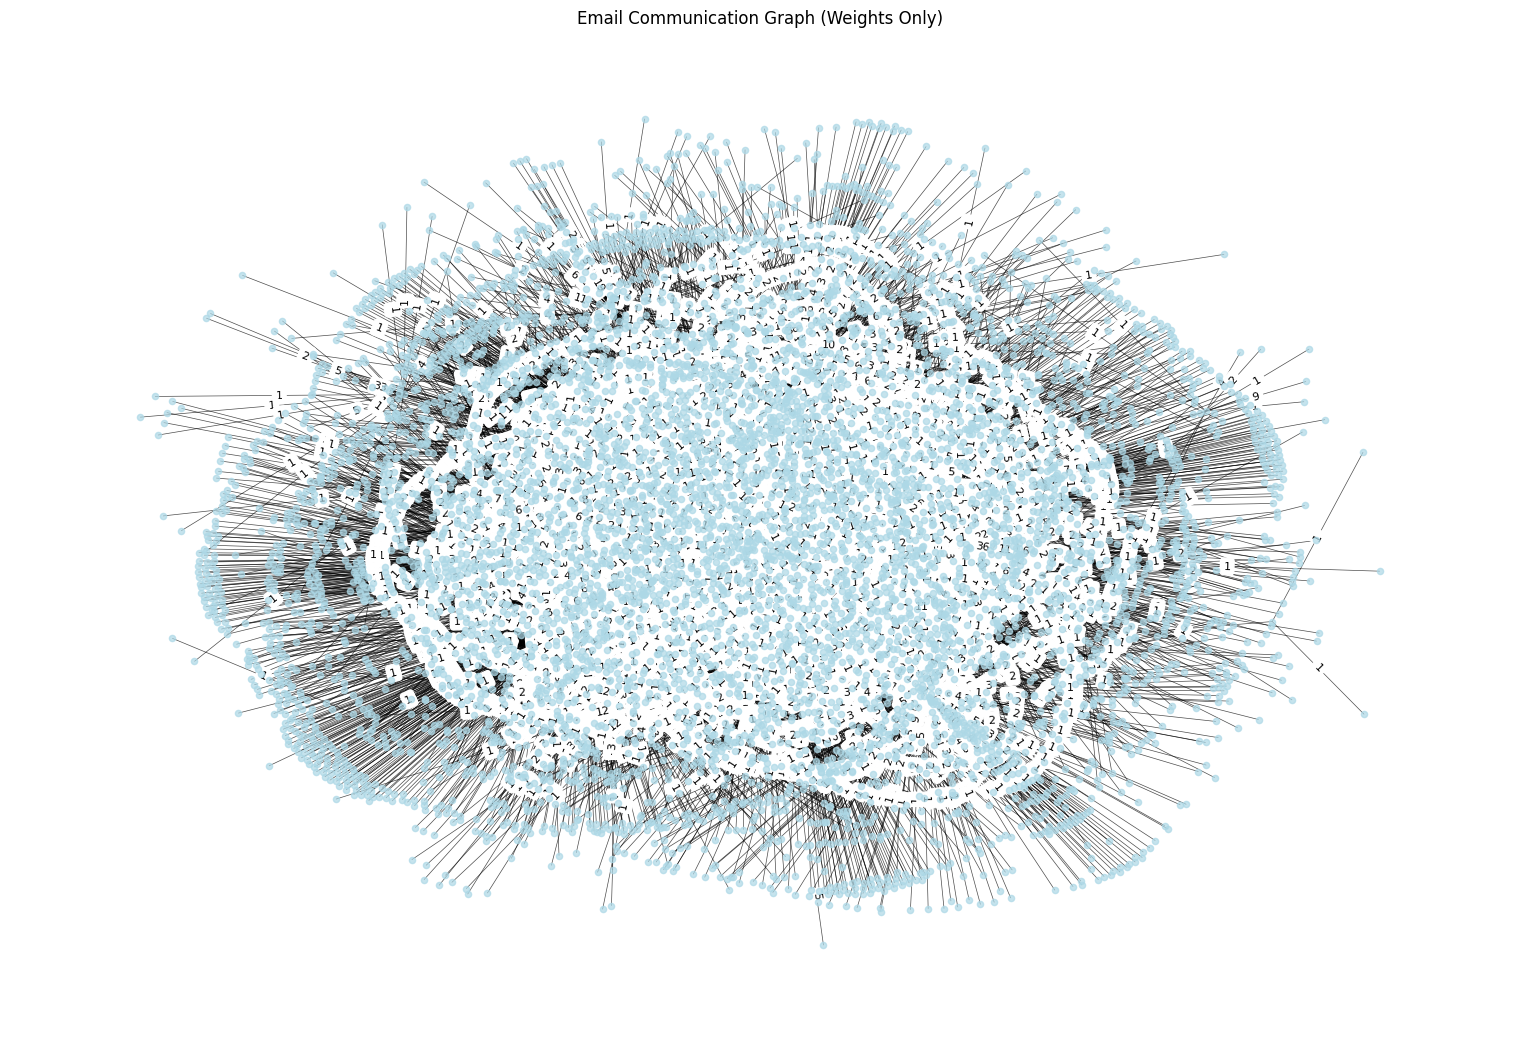

In [54]:
# your code here
# Visualize the graph
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.1)


nx.draw(G, pos, with_labels=False, node_size=20, node_color="lightblue", alpha=0.7, width=0.5)


edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Email Communication Graph (Weights Only)")
plt.show()

In [59]:
most_connected_users = sorted(G.degree, key=lambda x: x[1], reverse=True)[:2]
top_2_connected = [user for user, degree in most_connected_users]


isolated_users = list(nx.isolates(G))[:2]


most_edges_node = max(G.degree, key=lambda x: x[1])[0]


print("Two most connected users:", top_2_connected)
print("Two isolated users:", isolated_users)
print("Node with the most edges:", most_edges_node)


Two most connected users: ['sally.beck@enron.com', 'vince.kaminski@enron.com']
Two isolated users: []
Node with the most edges: sally.beck@enron.com


### Observation of the graph (5 points)

What can you observe from the graph? Is there any user who is the center of the graph? Is there any user who is isolated from the graph? Which node has the most edges? Please provide your observations in bullet points based on the visualization.

Your output should look like this:


```text
* Observation 1:
* Observation 2:
* Observation 3:
```

```text
* Majority of the nodes are concentrated at the center and saturated, while a significant number of nodes also lie outside the large main cluster
* According to me, sally.beck@enron.com and vince.kaminski@enron.com are at the center of the graph.
* I did not find any significant isolated node in the graph.
* sally.beck@enron.com has the most number of edges.
```

# Part 2: Link-based Ranking (50 points)

---

In this part, over the graph you built, we're going to adapt the classic PageRank and  Hubs-and-Authorities approaches to allow us to find the most important users. So, instead of viewing the world as web pages with hyperlinks (where pages = nodes, hyperlinks = edges), we view it as users in an email network.


### A: PageRank (10 points)
Given this graph, your first job is to simply run PageRank to find the highest ranking users. You may use the [built-in pagerank](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html) function in networkx.

Print the top-5 highest PageRank scores in `user: score` format.

In [55]:
# your code here
pagerank_scores = nx.pagerank(G)


top5_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]


print("Top 5 PageRank Scores:")
for user, score in top5_pagerank:
    print(f"{user}: {score:.6f}")

Top 5 PageRank Scores:
vince.kaminski@enron.com: 0.039606
kay.mann@enron.com: 0.029068
sally.beck@enron.com: 0.028239
jeff.skilling@enron.com: 0.027883
mary.hain@enron.com: 0.024503


### B: Personalized PageRank (10 points)
In class, we focused on the traditional "vanilla" PageRank where the teleportation factor is uniform -- that is, the random surfer occasionally is bored and will teleport randomly to a node in the graph. Instead, we can bias the teleportation to a subset of nodes in the graph. This is called Personalized PageRank! The idea is that the PageRank scores will be biased towards nodes near the ones that you teleport to.

For this problem assume the user of interest is `"john.arnold@enron.com"`. You should compute the personalized PageRank and print the top-5 highest personalized PageRank scores in `user: score` format. Note that there is a nice function parameter called "personalization" in the built-in pagerank that you can use for this problem.

In [56]:
# your code here

personalization = {user: 0 for user in G.nodes()}
personalization["john.arnold@enron.com"] = 1


personalized_pagerank_scores = nx.pagerank(G, personalization=personalization)


top5_personalized_pagerank = sorted(personalized_pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]


print("Top 5 Personalized PageRank Scores:")
for user, score in top5_personalized_pagerank:
    print(f"{user}: {score:.6f}")

Top 5 Personalized PageRank Scores:
john.arnold@enron.com: 0.257648
john.lavorato@enron.com: 0.024862
vince.kaminski@enron.com: 0.023668
sally.beck@enron.com: 0.017205
kay.chapman@enron.com: 0.016490


### C: Hubs and Authorities (20 points)
Just like we can calculate PageRank over the user graph, we can also find the hub and authority scores for users.

For this part, you should return the top-5 users with highest Hub scores and the top-5 users with the highest Authority scores. The **output** should be like:

`Hub Scores`

`1. user1: score1`

`...`

`Authority Scores`

`1. user1: score1`

` ...`




In [57]:
# Your code here

hub_scores, authority_scores = nx.hits(G)


top5_hubs = sorted(hub_scores.items(), key=lambda x: x[1], reverse=True)[:5]

top5_authorities = sorted(authority_scores.items(), key=lambda x: x[1], reverse=True)[:5]


print("Hub Scores:")
for i, (user, score) in enumerate(top5_hubs, start=1):
    print(f"{i}. {user}: {score:.6f}")


print("\nAuthority Scores:")
for i, (user, score) in enumerate(top5_authorities, start=1):
    print(f"{i}. {user}: {score:.6f}")

Hub Scores:
1. vince.kaminski@enron.com: 0.223860
2. vkaminski@aol.com: 0.208650
3. shirley.crenshaw@enron.com: 0.059590
4. stinson.gibner@enron.com: 0.023410
5. mike.roberts@enron.com: 0.010822

Authority Scores:
1. vince.kaminski@enron.com: 0.223860
2. vkaminski@aol.com: 0.208650
3. shirley.crenshaw@enron.com: 0.059590
4. stinson.gibner@enron.com: 0.023410
5. mike.roberts@enron.com: 0.010822


### Discussion (10 points)
Briefly discuss the differences you see between the three methods. You should play with the personalization parameters in PageRank and show some findings.


*your discussion here*

1) Standard PageRank identifies vince.kaminski@enron.com as the most important node, but Personalized PageRank puts john.arnold@enron.com at the top with a significantly higher score.

2) The Personalized PageRank results show a more concentrated distribution of importance, with John Arnold's score being about 10 times higher than the second-ranked person. On the other side, standard PageRank shows a more gradual decrease in scores.

3) Three out of five top-ranked individuals (Vince Kaminski, Sally Beck, and Kay Mann/Chapman) appear in both PageRank lists, which indicates some consistency between the methods.

4) The HITS algorithm produces identical Hub and Authority scores for the top 5 nodes, which is unusual and suggests a specific network structure.

5) Vince Kaminski appears as the top-ranked node in both Hub and Authority scores, aligning with his high ranking in standard PageRank.

6) The HITS algorithm identifies vkaminski@aol.com as the second most important node, which doesn't appear in the top 5 for either PageRank method. This could indicate a different type of importance captured by HITS

7) On experimenting with personalization parameters in PageRank:

 -> If I increase the personalization weight for known Enron executives (e.g., jeff.skilling@enron.com), I see a rise in their rankings.

# Collaboration Declarations

*You should fill out your collaboration declarations here.*

I used chatgpt to debug my code.

Discussed approaches with peers.

Compared my results with others jsut to get a sense if im in the right direction.

Referred the link given above for visualizing the graph.